# Predicting Exotic Particles With Machine Learning

In 2014, the paper [Searching for Exotic Particles in High-Energy Physics with Deep Learning](https://arxiv.org/pdf/1402.4735) (P. Baldi, P. Sadowski, and D. Whiteson of UV, Irvine) discusses how to use machine learning to predict Higgs Boson particles using various measurements that are taken from a collider. There are two main feature sets that are used:

1. Low-level features: These features (inputs) are raw features that are measured from experiments.
2. High-level features: These features are derived manually from the raw inputs. This is fairly labor-intensive.

They were able to successfully improve the Area Under the Curve (AUC) using deep learning and a combination of the low-level and high-level features produced from Monte Carlo simulations. If it is possible to create predictions with low-level features that are equal to or better than high-level features, then time can be saved by not spending time deriving the high-level features. In the paper, they were able to prove that a deep neural network did nearly as well learning from low-level features as it did with the complete feature set. Deep neural networks require more feature engineering, sophisticated interpretability tools, and GPUs to run efficiently.

**Project Goals**
1. Create a tuned machine learning model with low-level features that are as good or better than high-level features
2. Build a model that is equal to or better than the Boosted Decision Tree (BDT) or shallow Neural Network (NN) models in the paper
3. Use equivalent hardware without the need of a GPU

**Dataset**

https://archive.ics.uci.edu/dataset/280/higgs

**Topics**
- Machine Learning
- Hyperparameter Autotuning
- Big Data
- Visualization

In [78]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import optuna.visualization as vis
import plotly.io as pio
import warnings
from pathlib import Path
from zipfile import ZipFile
from isal import igzip
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.pipeline import make_pipeline
from sasviya.ml.linear_model import LogisticRegression
from sasviya.ml.svm import SVC
from sasviya.ml.tree import DecisionTreeClassifier, ForestClassifier, GradientBoostingClassifier

warnings.filterwarnings(action='ignore', category=FutureWarning)

# Location of accuracy and hyperparameter optimization studies
study_loc = Path.cwd() / "studies"

### Read Data

Read in the higgs dataset. This dataset can be found at the UC Irvine Machine Learning repository:
https://archive.ics.uci.edu/dataset/280/higgs

It is a csv file in a gz file encapsulated in a zip file. We'll need to unwrap everything to get to the csv file.

In [2]:
file = '/workspaces/myfolder/data/higgs.zip'

col_names = ['signal', 'lepton_pt', 'lepton_eta', 'lepton_phi', 
             'missing_energy_magnitude', 'missing_energy_phi',
             'jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_btag',
             'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_btag',
             'jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_btag',
             'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_btag',
             'm_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

In [3]:
with ZipFile(file, 'r') as zip_file:
    with zip_file.open('HIGGS.csv.gz') as gz_file:
        with igzip.open(gz_file, 'rt') as csv_file:
            df = pl.read_csv(csv_file, has_header=False, new_columns=col_names).to_pandas() # This is way faster than pd.read_csv

### Exploratory Data Analysis

Let's take a look at the underlying data and see how it all looks. The data is entirely numeric, has no missing values, is well-balanced with a 53/47 split, and almost all variables have a low correlation with each other. It's excellent for machine learning.

General statistics

In [39]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
signal,11000000.0,0.529920,0.499104,0.000000,0.000000,1.000000,1.000000,1.000000
lepton_pt,11000000.0,0.991466,0.565378,0.274697,0.590753,0.853371,1.236226,12.098914
lepton_eta,11000000.0,-0.000008,1.008827,-2.434976,-0.738322,-0.000054,0.738214,2.434868
lepton_phi,11000000.0,-0.000013,1.006346,-1.742508,-0.871931,-0.000241,0.870994,1.743236
missing_energy_magnitude,11000000.0,0.998536,0.600018,0.000237,0.576816,0.891628,1.293056,15.396821
missing_energy_phi,11000000.0,0.000026,1.006326,-1.743944,-0.871208,0.000213,0.871471,1.743257
jet_1_pt,11000000.0,0.990915,0.474975,0.137502,0.678993,0.894819,1.170740,9.940391
jet_1_eta,11000000.0,-0.000020,1.009303,-2.969725,-0.687245,-0.000025,0.687194,2.969674
jet_1_phi,11000000.0,0.000008,1.005901,-1.741237,-0.868096,0.000058,0.868313,1.741454
jet_1_btag,11000000.0,0.999969,1.027808,0.000000,0.000000,1.086538,2.173076,2.173076


Null value counts

In [54]:
df.isnull().sum().sum()

0

Check the balance of signal

In [5]:
df['signal'].value_counts(normalize=True)

signal
1.0    0.52992
0.0    0.47008
Name: proportion, dtype: float64

### Correlation Matrix

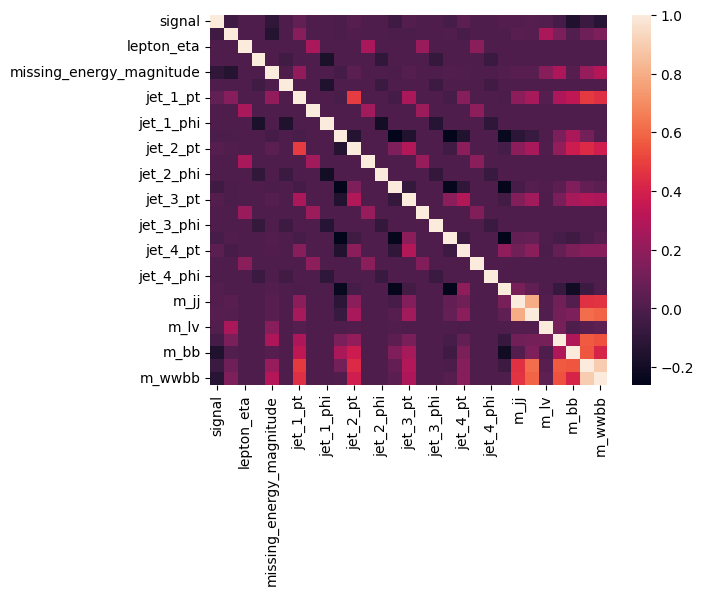

In [4]:
sns.heatmap(df.corr());

### Variable Distribution

In [41]:
df_sample = df.sample(1000, random_state=42)

#### Distribution of high-level variables

In [ ]:
sns.pairplot(
    df_sample[['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']], 
    kind='kde', 
    corner=True
);

#### Distribution of low-level variables: lepton_eta and missing_energy_magnitude

In [ ]:
sns.pairplot(
    df_sample[['lepton_eta', 'missing_energy_magnitude']], 
    kind='kde', 
    corner=True
);

#### Distribution of low-level variables: jet_1-jet_2

In [ ]:
sns.pairplot(
    df_sample[['jet_1_pt', 'jet_1_eta', 'jet_1_phi', 'jet_1_btag', 'jet_2_pt', 'jet_2_eta', 'jet_2_phi', 'jet_2_btag']], 
    kind='kde', 
    corner=True
);

#### Distribution of low-level variables: jet_3-jet_4

In [ ]:
sns.pairplot(
    df_sample[['jet_3_pt', 'jet_3_eta', 'jet_3_phi', 'jet_3_btag', 'jet_4_pt', 'jet_4_eta', 'jet_4_phi', 'jet_4_btag']], 
    kind='kde', 
    corner=True
);

### Create X and y dataframes

In [6]:
X = df.drop('signal', axis=1)
y = df['signal']

### Preliminary Model Selection

We have a lot of models to choose from, and we want to narrow it down to one. We'll do a preliminary test using 5-fold cross-validation using the following models:

- Logistic Regression
- SVC
- Decision Tree
- Random Forest
- Gradient Boosting

This will give us a good starting point for a model to tune later. 

**This may take some time to run on the full dataset, so consider skipping running this and use the saved accuracy results instead. To run a test, you must confirm the prompt with Y**

In [ ]:
check = input('Are you sure you want to run a new test? WARNING: this will overwrite the previous test. Y/N')

if check == 'Y':
    models = [
        ('Logistic Regression', make_pipeline(StandardScaler(), LogisticRegression()) ),
        ('SVM', make_pipeline(StandardScaler(), SVC()) ),
        ('Decision Tree', DecisionTreeClassifier()), 
        ('Random Forest', ForestClassifier()),
        ('Gradient Boosting', GradientBoostingClassifier()),
    ]

    folds = 5

    print(f'Testing {folds}-fold cross-validation accuracy for {len(models)} models\n')

    i = 0
    scores = {}
    for name, model in models:
        i+=1

        print(f'{i}: {name}')
        scores[name]  = cross_val_score(model, X, y, cv=folds)
        
    df_accuracy  = pd.DataFrame(scores)
    df_accuracy.to_parquet(study_loc / 'accuracy.parquet')

Testing 5-fold cross-validation accuracy for 5 models

1: Logistic Regression
2: SVM
3: Decision Tree
4: Random Forest
5: Gradient Boosting


### Review preliminary accuracy results

We're looking for the model that has the best prediction accuracy on average, and we want to see what the standard deviation is throughout each fold. Given that the data is very balanced, we should expect that there is low variance.

In [30]:
df_accuracy = pd.read_parquet(study_loc / 'accuracy.parquet')
df_accuracy

,Logistic Regression,SVM,Decision Tree,Random Forest,Gradient Boosting
0,0.566126,0.562287,0.577392,0.619178,0.633220
1,0.566264,0.562161,0.578423,0.622332,0.633713
2,0.566528,0.562504,0.578295,0.620902,0.633915
3,0.566220,0.562610,0.576849,0.623043,0.633438
4,0.566327,0.562810,0.577996,0.619879,0.633706


In [31]:
df_accuracy_stats = (
  df_accuracy
  .describe()
  .transpose()[['mean', 'std']]
  .sort_values('mean', ascending=False)
)

df_accuracy_stats

,mean,std
Gradient Boosting,0.633599,0.000271
Random Forest,0.621067,0.001621
Decision Tree,0.577791,0.000660
Logistic Regression,0.566293,0.000150
SVM,0.562474,0.000258


Gradient boosting is the clear winner here, and it has virtually no variance among all 5 folds.

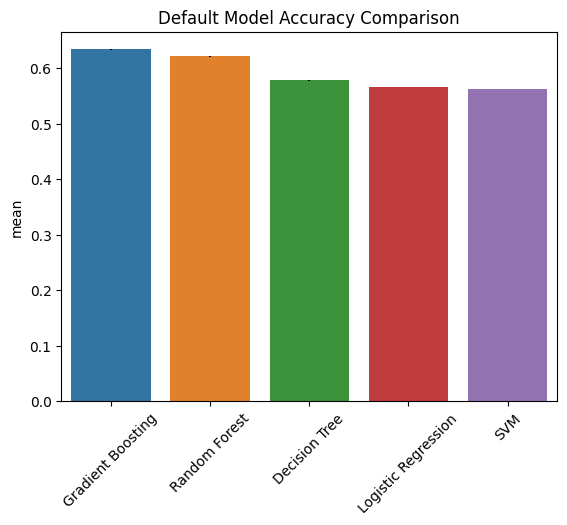

In [32]:
plt.title("Default Model Accuracy Comparison")
plt.xticks(rotation=45)

sns.barplot(
    x=df_accuracy_stats.index, 
    y=df_accuracy_stats['mean'], 
    yerr=df_accuracy_stats['std']
);


### Prepare for tuning

Split into train/validation/test:
- 70% Training
- 15% Validation
- 15% Test

We will tune against the validation dataset, then use the test dataset as our unbiased final measure of accuracy for generalization.

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [8]:
high_level = ['m_jj', 'm_jjj', 'm_lv', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

# Training/Validation/Test Split for low-level features
X_train_low  = X_train.drop(high_level, axis=1)
X_val_low    = X_val.drop(high_level, axis=1)
X_test_low   = X_test.drop(high_level, axis=1)

# Training/Validation/Test Split for high-level features
X_train_high = X_train[high_level]
X_val_high   = X_val[high_level]
X_test_high  = X_test[high_level]

# Clear up memory
del df, df_sample, X, y, X_train, X_val, X_test, X_temp, y_temp

NameError: name 'df_sample' is not defined

Confirm that the train/test/split is stratified with equal proportions

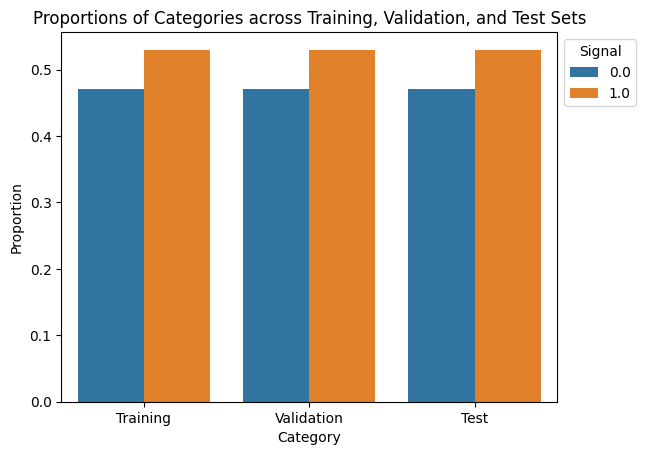

In [ ]:
y_train_props = y_train.value_counts(normalize=True).reset_index(name='Proportion')
y_train_props['Dataset'] = 'Training'

y_val_props = y_val.value_counts(normalize=True).reset_index(name='Proportion')
y_val_props['Dataset'] = 'Validation'

y_test_props = y_test.value_counts(normalize=True).reset_index(name='Proportion')
y_test_props['Dataset'] = 'Test'

all_proportions = pd.concat([y_train_props, y_val_props, y_test_props])

sns.barplot(data=all_proportions, x='Dataset', y='Proportion', hue='signal');

plt.title('Proportions of Categories across Training, Validation, and Test Sets')
plt.xlabel('Category')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Signal', loc='upper left', bbox_to_anchor=(1, 1));

### Autotune

We will autotune the models using Optuna, a Bayesian optimization hyperparameter autotuning framework. We will tune this using two models:

1. A model that only uses low-level variables
2. A model that only uses high-level variables

The goal is to see if we can make the low-level model as good, or better, than the high-level model. If we can tune it well enough, and ensure it is generalizable, then there is no need to go through the effort of deriving the high-level variables since the model has learned enough from the low-level variables to get equivalent or better predictions.

Our tuning method is to:
1. Train the model on the training dataset
2. Predict against the validation dataset
3. Calculate the Area Under the Curve (AUC)
4. Try to maximize the AUC

**These models have already been tuned and the study results are saved in the studies folder. Tuning will take time to complete. To tune a model, you must confirm the prompt with Y.**

Low-level autotuning

In [ ]:
def low_level_objective(trial):
    n_bins           = trial.suggest_int('n_bins', 10, 100, step=5)
    n_estimators     = trial.suggest_int('n_estimators', 50, 300, step=10)
    max_depth        = trial.suggest_int('max_depth', 5, 17)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 100, 1000, step=50)
    learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01)

    model = GradientBoostingClassifier(
        n_bins           = n_bins,
        n_estimators     = n_estimators,
        max_depth        = max_depth,
        min_samples_leaf = min_samples_leaf,
        learning_rate    = learning_rate,
        random_state     = 42
    )

    model.fit(X_train_low, y_train)
    
    preds = model.predict_proba(X_val_low).iloc[:,1]
    auc   = roc_auc_score(y_val, preds)

    return auc

In [ ]:
check = input('Are you sure you want to run a new study? WARNING: this will overwrite the previous study. Y/N')

if(check == 'Y'):
    low_level_study = optuna.create_study(
        direction  = 'maximize', 
        study_name = 'Low-level variables: Gradient Boosting Autotuning',
        storage    = f"sqlite:////{study_loc / 'low_level_study.db'}",
        load_if_exists=True
    )

    low_level_study.optimize(low_level_objective, n_trials=30)

High-level autotuning

In [ ]:
def high_level_objective(trial):
    n_bins           = trial.suggest_int('n_bins', 10, 100, step=5)
    n_estimators     = trial.suggest_int('n_estimators', 50, 300, step=10)
    max_depth        = trial.suggest_int('max_depth', 5, 17)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 100, 1000, step=50)
    learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01)

    model = GradientBoostingClassifier(
        n_bins           = n_bins,
        n_estimators     = n_estimators,
        max_depth        = max_depth,
        min_samples_leaf = min_samples_leaf,
        learning_rate    = learning_rate,
        random_state     = 42
    )

    model.fit(X_train_high, y_train)
    
    preds = model.predict_proba(X_val_high).iloc[:,1]
    auc   = roc_auc_score(y_val, preds)

    return auc

In [ ]:
check = input('Are you sure you want to run a new study? WARNING: this will overwrite the previous study. Y/N')

if(check == 'Y'):
    high_level_study = optuna.create_study(
        direction  = 'maximize', 
        study_name = 'High-level variables: Gradient Boosting Autotuning',
        storage    = f"sqlite:////{study_loc / 'high_level_study.db'}",
        load_if_exists=True    
    )

    high_level_study.optimize(high_level_objective, n_trials=30)

### Check Study Results

In [9]:
low_level_study = optuna.load_study(
    storage=f"sqlite:////{study_loc / 'low_level_study.db'}",
    study_name='Low-level variables: Gradient Boosting Autotuning'
)

high_level_study = optuna.load_study(
    storage=f"sqlite:////{study_loc / 'high_level_study.db'}",
    study_name='High-level variables: Gradient Boosting Autotuning'
)

Best parameters: Low-level variables

In [10]:
low_level_study.best_params

{'n_bins': 85,
 'n_estimators': 300,
 'max_depth': 16,
 'min_samples_leaf': 250,
 'learning_rate': 0.060000000000000005}

Best parameters: High-level variables

In [11]:
high_level_study.best_params

{'n_bins': 100,
 'n_estimators': 240,
 'max_depth': 13,
 'min_samples_leaf': 250,
 'learning_rate': 0.060000000000000005}

### Explore Hyperparameter Autotuning Results

Optuna comes with some really cool visualizations out of the box. We can look and see which variables were considered most important for tuning as well as the optimization history.

**Note: These use Plotly and will not display on GitHub**
##### Low-level study hyperparameter importances

In [ ]:
vis.plot_param_importances(low_level_study).show()

##### High-level study hyperparameter importances

In [ ]:
vis.plot_param_importances(high_level_study).show()

##### Low-level study optimization history

In [ ]:
vis.plot_optimization_history(low_level_study)

##### High-level study optimization history

In [ ]:
vis.plot_optimization_history(high_level_study)

##### Low-level study parallel coordinates plot

In [ ]:
vis.plot_parallel_coordinate(low_level_study).show()

##### High-level study parallel coordinates plot

In [ ]:
vis.plot_parallel_coordinate(high_level_study).show()

### Fit All Models

We will fit four models:
1. Default low
2. Default high
3. Tuned low
4. Tuned high

By including the default model, this will give us a good baseline to compare against

In [12]:
gboost_model_default_low  = GradientBoostingClassifier(random_state=42)
gboost_model_default_high = GradientBoostingClassifier(random_state=42)

gboost_model_tuned_low    = GradientBoostingClassifier(**low_level_study.best_params, random_state=42)
gboost_model_tuned_high   = GradientBoostingClassifier(**high_level_study.best_params, random_state=42)

gboost_model_default_low.fit(X_train_low, y_train)
gboost_model_default_high.fit(X_train_high, y_train)

gboost_model_tuned_low.fit(X_train_low, y_train)
gboost_model_tuned_high.fit(X_train_high, y_train)

GradientBoostingClassifier(min_samples_leaf=250, n_bins=100, n_estimators=240, max_depth=13, learning_rate=0.060000000000000005, random_state=42)

In [ ]:
gboost_model_default_low.save(model_path / "../modelsdefault_low.pickle")
gboost_model_default_high.save(model_path / "../models/default_high.pickle")
gboost_model_tuned_low.save(model_path / "../models/tuned_low.pickle")
gboost_model_tuned_high.save(model_path / "../models/tuned_high.pickle")

#### Generate predictions

Create validation and test predictions for each model type:
- Default low-level features
- Default high-level features
- Tuned low-level features
- Tuned high-level features

In [ ]:
val_preds = pd.DataFrame(
    {
        'signal': y_val,
        'p_signal_default_low':  gboost_model_default_low.predict_proba(X_val_low).iloc[:,1],
        'p_signal_default_high': gboost_model_default_high.predict_proba(X_val_high).iloc[:,1],
        'p_signal_tuned_low':    gboost_model_tuned_low.predict_proba(X_val_low).iloc[:,1],
        'p_signal_tuned_high':   gboost_model_tuned_high.predict_proba(X_val_high).iloc[:,1]
    }
)

test_preds = pd.DataFrame(
    {
        'signal': y_test,
        'p_signal_default_low':  gboost_model_default_low.predict_proba(X_test_low).iloc[:,1],
        'p_signal_default_high': gboost_model_default_high.predict_proba(X_test_high).iloc[:,1],
        'p_signal_tuned_low':    gboost_model_tuned_low.predict_proba(X_test_low).iloc[:,1],
        'p_signal_tuned_high':   gboost_model_tuned_high.predict_proba(X_test_high).iloc[:,1]
    }
)


#### Calculate ROC curves

**Default Model**: Low-level features

In [69]:
preds = 'p_signal_default_low'

default_low_val_fpr, default_low_val_tpr, default_low_val_thresholds    = roc_curve(y_val, val_preds[preds])
default_low_test_fpr, default_low_test_tpr, default_low_test_thresholds = roc_curve(y_test, test_preds[preds])

default_low_val_auc  = roc_auc_score(y_val, val_preds[preds])
default_low_test_auc = roc_auc_score(y_test, test_preds[preds])

**Default Model**: High-level features

In [70]:
preds = 'p_signal_default_high'

default_high_val_fpr, default_high_val_tpr, default_high_val_thresholds    = roc_curve(val_preds['signal'], val_preds[preds])
default_high_test_fpr, default_high_test_tpr, default_high_test_thresholds = roc_curve(test_preds['signal'], test_preds[preds])

default_high_val_auc  = roc_auc_score(val_preds['signal'], val_preds[preds])
default_high_test_auc = roc_auc_score(test_preds['signal'], test_preds[preds])

**Tuned Model**: Low-level features

In [71]:
preds = 'p_signal_tuned_low'

tuned_low_val_fpr, tuned_low_val_tpr, tuned_low_val_thresholds    = roc_curve(val_preds['signal'], val_preds[preds])
tuned_low_test_fpr, tuned_low_test_tpr, tuned_low_test_thresholds = roc_curve(test_preds['signal'], test_preds[preds])

tuned_low_val_auc  = roc_auc_score(val_preds['signal'], val_preds[preds])
tuned_low_test_auc = roc_auc_score(test_preds['signal'], test_preds[preds])

**Tuned Model**: High-level features

In [72]:
preds = 'p_signal_tuned_high'

tuned_high_val_fpr, tuned_high_val_tpr, tuned_high_val_thresholds    = roc_curve(val_preds['signal'], val_preds[preds])
tuned_high_test_fpr, tuned_high_test_tpr, tuned_high_test_thresholds = roc_curve(test_preds['signal'], test_preds[preds])

tuned_high_val_auc  = roc_auc_score(val_preds['signal'], val_preds[preds])
tuned_high_test_auc = roc_auc_score(test_preds['signal'], test_preds[preds])

### Plot ROC Curves and Accuracy

With a **Test AUC of 0.795**, the low-level model is nearly as good as the high-level model with a **Test AUC of 0.796**. Both models beat the default model with a **Test AUC of 0.69**, and even beat both the paper's BDT and shallow NN models.

| Model            | AUC: Low-level  | AUC: High-level |
| ---------------- | --------------- | --------------- |
| Paper: BDT       | 0.73            | 0.78            |
| Paper: NN        | 0.733           | 0.777           |
| Paper: DN        | 0.880           | 0.885           |
| Default GBoost   | 0.686           | 0.777           |
| **Tuned GBoost** | **0.795**       | **0.796**       |

The validation and test results show identical AUCs, suggesting excellent generalization of this model. This means it is possible to create a tuned gradient boosting model in short time without the need of GPU acceleration for deep learning to create a model that is more accurate than the paper's BDT and shallow NN.

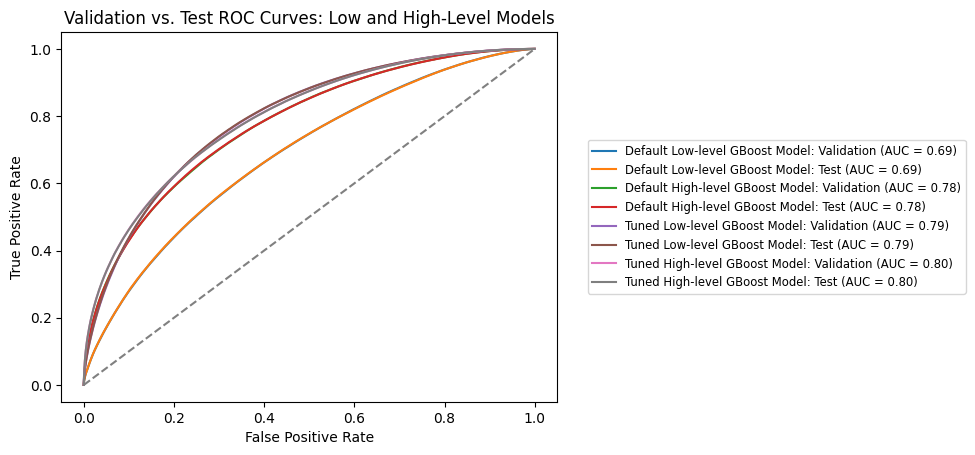

In [73]:
fig, ax = plt.subplots()

# Default model: Low-level
default_low_val_roc_display  = RocCurveDisplay(fpr=default_low_val_fpr, tpr=default_low_val_tpr, roc_auc=default_low_val_auc)
default_low_test_roc_display = RocCurveDisplay(fpr=default_low_test_fpr, tpr=default_low_test_tpr, roc_auc=default_low_test_auc)

# Default model: High-level
default_high_val_roc_display  = RocCurveDisplay(fpr=default_high_val_fpr, tpr=default_high_val_tpr, roc_auc=default_high_val_auc)
default_high_test_roc_display = RocCurveDisplay(fpr=default_high_test_fpr, tpr=default_high_test_tpr, roc_auc=default_high_test_auc)

# Tuned model: Low-level
tuned_low_val_roc_display  = RocCurveDisplay(fpr=tuned_low_val_fpr, tpr=tuned_low_val_tpr, roc_auc=tuned_low_val_auc)
tuned_low_test_roc_display = RocCurveDisplay(fpr=tuned_low_test_fpr, tpr=tuned_low_test_tpr, roc_auc=tuned_low_test_auc)

# Tuned model: High-level
tuned_high_val_roc_display  = RocCurveDisplay(fpr=tuned_high_val_fpr, tpr=tuned_high_val_tpr, roc_auc=tuned_high_val_auc)
tuned_high_test_roc_display = RocCurveDisplay(fpr=tuned_high_test_fpr, tpr=tuned_high_test_tpr, roc_auc=tuned_high_test_auc)

# Plot all models on one axis
default_low_val_roc_display.plot(ax=ax, name='Default Low-level GBoost Model: Validation')
default_low_test_roc_display.plot(ax=ax, name='Default Low-level GBoost Model: Test')

default_high_val_roc_display.plot(ax=ax, name='Default High-level GBoost Model: Validation')
default_high_test_roc_display.plot(ax=ax, name='Default High-level GBoost Model: Test')

tuned_low_val_roc_display.plot(ax=ax, name='Tuned Low-level GBoost Model: Validation')
tuned_low_test_roc_display.plot(ax=ax, name='Tuned Low-level GBoost Model: Test')

tuned_high_val_roc_display.plot(ax=ax, name='Tuned High-level GBoost Model: Validation')
tuned_high_test_roc_display.plot(ax=ax, name='Tuned High-level GBoost Model: Test')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize='small')

plt.title('Validation vs. Test ROC Curves: Low and High-Level Models')

plt.show()

In [ ]:
scenarios = [
    ("Validation, default low-level model", val_preds, 'p_signal_default_low'),
    ("Test, default low-level model", test_preds, 'p_signal_default_low'),
    ("Validation, default high-level model", val_preds, 'p_signal_default_high'),
    ("Test, default high-level model", test_preds, 'p_signal_default_high'),
    ("Validation, tuned low-level model", val_preds, 'p_signal_tuned_low'),
    ("Test, tuned low-level model", test_preds, 'p_signal_tuned_low'),
    ("Validation, tuned high-level model", val_preds, 'p_signal_tuned_high'),
    ("Test, tuned high-level model", test_preds, 'p_signal_tuned_high')
]

for label, df, pred_col in scenarios:
    score = accuracy_score(df['signal'], (df[pred_col] >= 0.5).astype(int))
    print(f"Accuracy score: {label}\n    {score:.4f}\n")

Accuracy score: Validation, default low-level model
    0.6326

Accuracy score: Test, default low-level model
    0.6331

Accuracy score: Validation, default high-level model
    0.7010

Accuracy score: Test, default high-level model
    0.7016

Accuracy score: Validation, tuned low-level model
    0.7212

Accuracy score: Test, tuned low-level model
    0.7218

Accuracy score: Validation, tuned high-level model
    0.7165

Accuracy score: Test, tuned high-level model
    0.7161



### Tuned Low-level Model: Validation Confusion Matrix

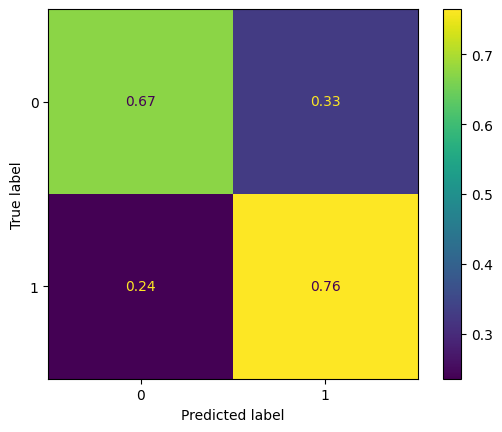

In [100]:
ConfusionMatrixDisplay(
    confusion_matrix(
        val_preds['signal'], 
        (val_preds['p_signal_tuned_low'] >= 0.5).astype(int),
        normalize='true'
    )
).plot();

### Tuned Low-level Model: Test Confusion Matrix

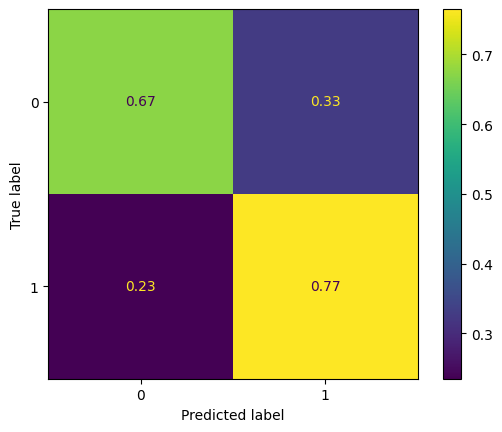

In [101]:
ConfusionMatrixDisplay(
    confusion_matrix(
        test_preds['signal'], 
        (test_preds['p_signal_tuned_low'] >= 0.5).astype(int),
        normalize='true'
    )
).plot();